In [1]:
import os
import json
import random
import pickle
import datetime

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


2026-05-10 18:51:00.697059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778439060.886214      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778439060.940498      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778439061.379589      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778439061.379626      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778439061.379629      22 computation_placer.cc:177] computation placer alr

In [2]:
SEEDS = [42, 123, 2024, 3407, 777]

BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 5
IMAGE_SIZE = (256, 256)
AUTOTUNE = tf.data.AUTOTUNE

EXPERIMENT_NAME = "CustomLightweightCNN_2_&"


In [3]:
DATASET_DIR = "/kaggle/input/datasets/shahadhossin567r7455/potato-leaf-disease-dataset/Potato Leaf DIsease"


In [4]:
class_names = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

NUM_CLASSES = len(class_names)

print("Dataset directory:", DATASET_DIR)
print("Detected classes:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("Number of classes:", NUM_CLASSES)


Dataset directory: /kaggle/input/datasets/shahadhossin567r7455/potato-leaf-disease-dataset/Potato Leaf DIsease
Detected classes:
0: Early Blight
1: Fungal Diseases
2: Healthy
3: Late Blight
4: Plant Pests
5: Potato Cyst Nematode
6: Potato Virus
Number of classes: 7


In [5]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

file_paths = []
labels = []

for label_index, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)

    for fname in os.listdir(class_dir):
        if fname.lower().endswith(valid_extensions):
            file_paths.append(os.path.join(class_dir, fname))
            labels.append(label_index)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total images:", len(labels))

unique, counts = np.unique(labels, return_counts=True)
print("\nClass distribution:")
for idx, count in zip(unique, counts):
    print(f"{class_names[idx]}: {count}")


Total images: 3500

Class distribution:
Early Blight: 500
Fungal Diseases: 500
Healthy: 500
Late Blight: 500
Plant Pests: 500
Potato Cyst Nematode: 500
Potato Virus: 500


In [6]:
def load_dataset_cnn(file_paths, labels, augment=False, shuffle=True, seed=None):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def process(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])

        image = tf.image.resize(image, IMAGE_SIZE)
        image = tf.cast(image, tf.float32) / 255.0

        if augment:
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, max_delta=0.1)
            image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
            image = tf.clip_by_value(image, 0.0, 1.0)

        label = tf.one_hot(label, depth=NUM_CLASSES)

        return image, label

    ds = ds.map(process, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(file_paths),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds


In [7]:
def build_custom_lightweight_cnn(num_classes, input_shape=(256, 256, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="CustomLightweightCNN")

    return model


In [8]:
def count_model_parameters(model):
    total_params = model.count_params()

    trainable_params = np.sum([
        np.prod(v.shape) for v in model.trainable_weights
    ])

    non_trainable_params = np.sum([
        np.prod(v.shape) for v in model.non_trainable_weights
    ])

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Non-trainable parameters: {non_trainable_params:,}")

    return total_params, trainable_params, non_trainable_params


In [9]:
def run_single_seed(seed):
    print("\n" + "=" * 70)
    print(f"Running seed: {seed}")
    print("=" * 70)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    X_train, X_temp, y_train, y_temp = train_test_split(
        file_paths,
        labels,
        test_size=0.20,
        stratify=labels,
        random_state=seed
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=seed
    )

    print(f"Train: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    class_weight_vals = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=y_train
    )
    class_weight = dict(enumerate(class_weight_vals))
    print("Class weights:", class_weight)

    train_ds = load_dataset_cnn(X_train, y_train, augment=True, shuffle=True, seed=seed)
    val_ds = load_dataset_cnn(X_val, y_val, augment=False, shuffle=False, seed=seed)
    test_ds = load_dataset_cnn(X_test, y_test, augment=False, shuffle=False, seed=seed)

    model = build_custom_lightweight_cnn(num_classes=NUM_CLASSES)

    total_params, trainable_params, non_trainable_params = count_model_parameters(model)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    os.makedirs("models", exist_ok=True)
    os.makedirs("history", exist_ok=True)
    os.makedirs("reports", exist_ok=True)

    run_name = f"{EXPERIMENT_NAME}_{NUM_CLASSES}class_seed_{seed}"

    model_path = f"models/{run_name}.keras"
    history_path = f"history/{run_name}_history.pkl"
    plot_path = f"history/{run_name}_accuracy_loss.png"
    cm_path = f"history/{run_name}_confusion_matrix.png"
    report_path = f"reports/{run_name}_classification_report.json"

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop, checkpoint],
        class_weight=class_weight
    )

    stopped_epoch = len(history.history["loss"])
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    with open(history_path, "wb") as f:
        pickle.dump(history.history, f)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    y_true = []
    y_pred = []

    for images, batch_labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(batch_labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    with open(report_path, "w") as f:
        json.dump(report_dict, f, indent=4)

    print(f"\nSeed {seed} Test Accuracy: {test_acc:.4f}")
    print(f"Seed {seed} Test Loss: {test_loss:.4f}")
    print(f"Seed {seed} Stopped Epoch: {stopped_epoch}")
    print(f"Seed {seed} Best Epoch: {best_epoch}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        xticks_rotation=45
    )
    plt.title(f"Confusion Matrix - Seed {seed}")
    plt.tight_layout()
    plt.savefig(cm_path, dpi=300)
    plt.show()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.show()

    result = {
        "seed": seed,
        "num_classes": NUM_CLASSES,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "stopped_epoch": stopped_epoch,
        "best_epoch": best_epoch,
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_precision": report_dict["weighted avg"]["precision"],
        "weighted_recall": report_dict["weighted avg"]["recall"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"],
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "model_path": model_path,
        "history_path": history_path,
        "plot_path": plot_path,
        "confusion_matrix_path": cm_path,
        "classification_report_path": report_path
    }

    return result



Running seed: 42
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}


I0000 00:00:1778439086.235764      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Total parameters: 381,255
Trainable parameters: 381,255
Non-trainable parameters: 0.0
Epoch 1/50


I0000 00:00:1778439096.532160      65 service.cc:152] XLA service 0x7d3e60213b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778439096.532209      65 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778439097.039871      65 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/88 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.1354 - loss: 1.9473  

I0000 00:00:1778439102.078620      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - accuracy: 0.2261 - loss: 1.8233 - val_accuracy: 0.3371 - val_loss: 1.5700
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.3563 - loss: 1.5825 - val_accuracy: 0.4371 - val_loss: 1.3437
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.4625 - loss: 1.3399 - val_accuracy: 0.5371 - val_loss: 1.2550
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.5227 - loss: 1.1945 - val_accuracy: 0.5886 - val_loss: 1.0533
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.5904 - loss: 1.0532 - val_accuracy: 0.6543 - val_loss: 0.9126
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.6438 - loss: 0.9457 - val_accuracy: 0.6571 - val_loss: 0.9116
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.6686 - loss: 0.8679 - val_accuracy: 0.6943 - val_loss: 0.8811
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.6749 - loss: 0.8330 - val_accuracy: 0.6857 - val_loss: 

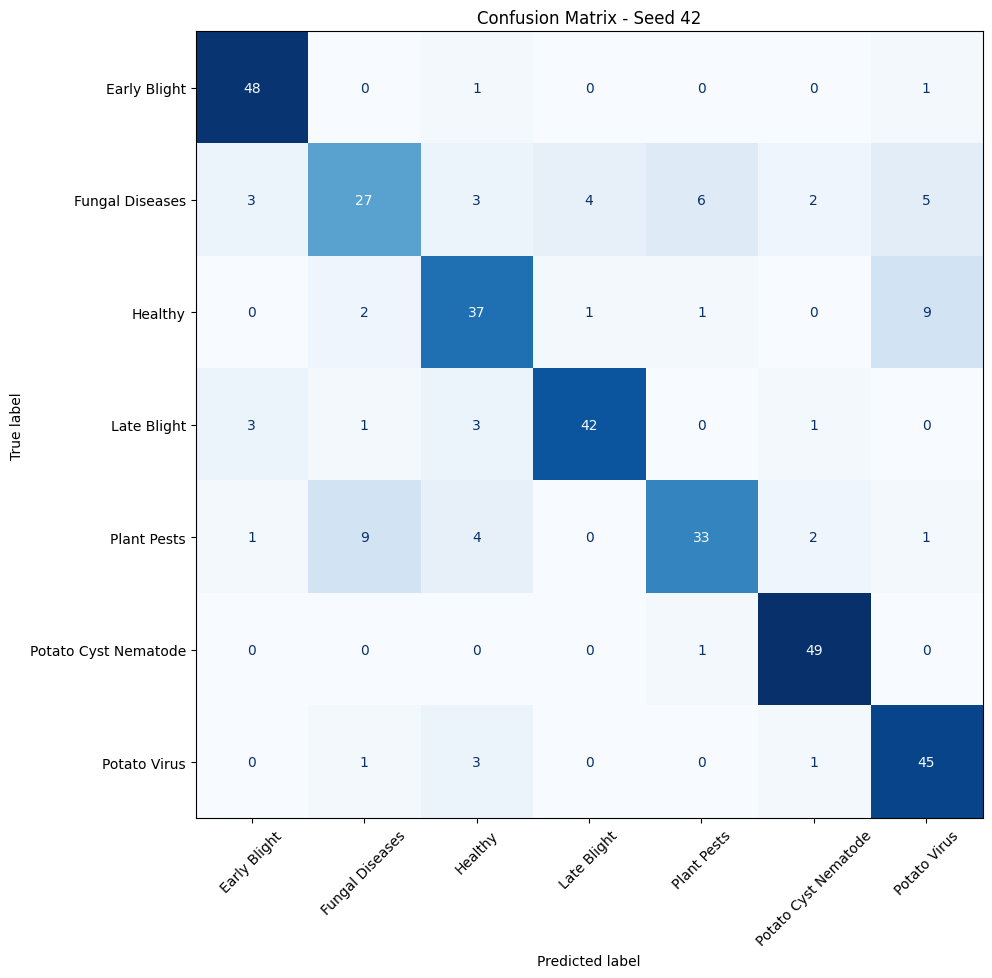

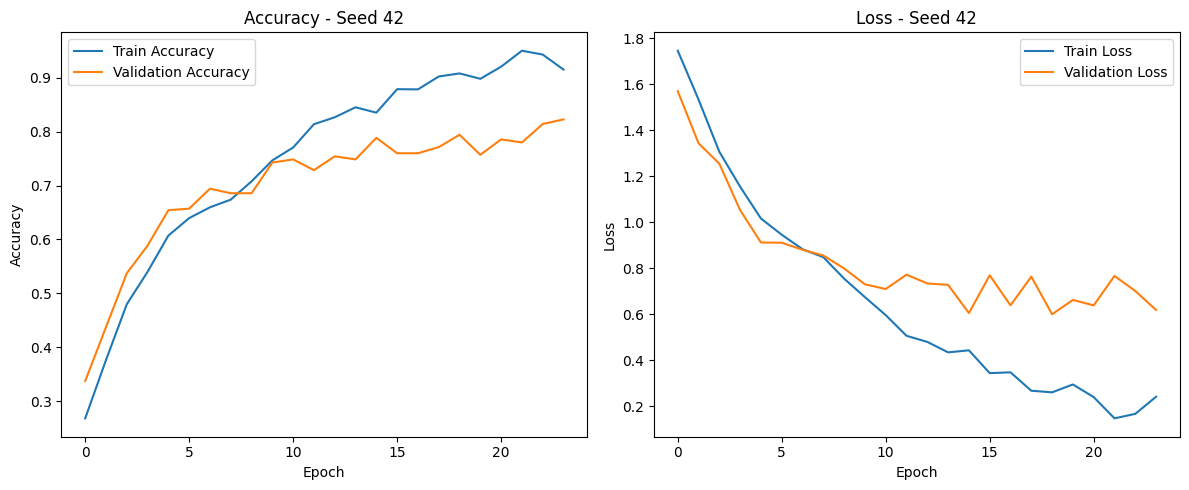


Running seed: 123
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}
Total parameters: 381,255
Trainable parameters: 381,255
Non-trainable parameters: 0.0
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.1912 - loss: 1.8696 - val_accuracy: 0.3171 - val_loss: 1.6285
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.3465 - loss: 1.5617 - val_accuracy: 0.3114 - val_loss: 1.6147
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.4454 - loss: 1.3926 - val_accuracy: 0.5629 - val_loss: 1.1673
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.5371 - loss: 1.1731 - val_accuracy: 0.5943 - val_loss: 1.0672
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.5943 - loss: 1.0369 - val_accuracy: 0.5971 - val_loss: 1.1453
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.

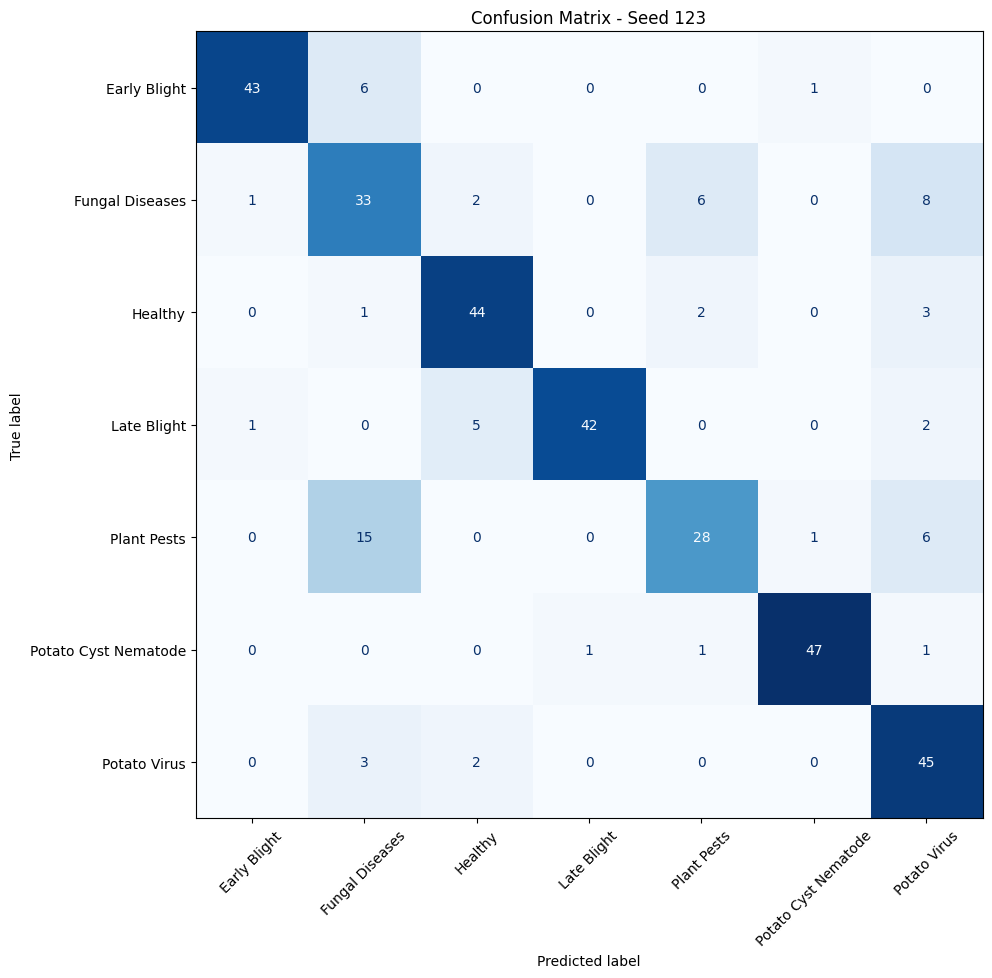

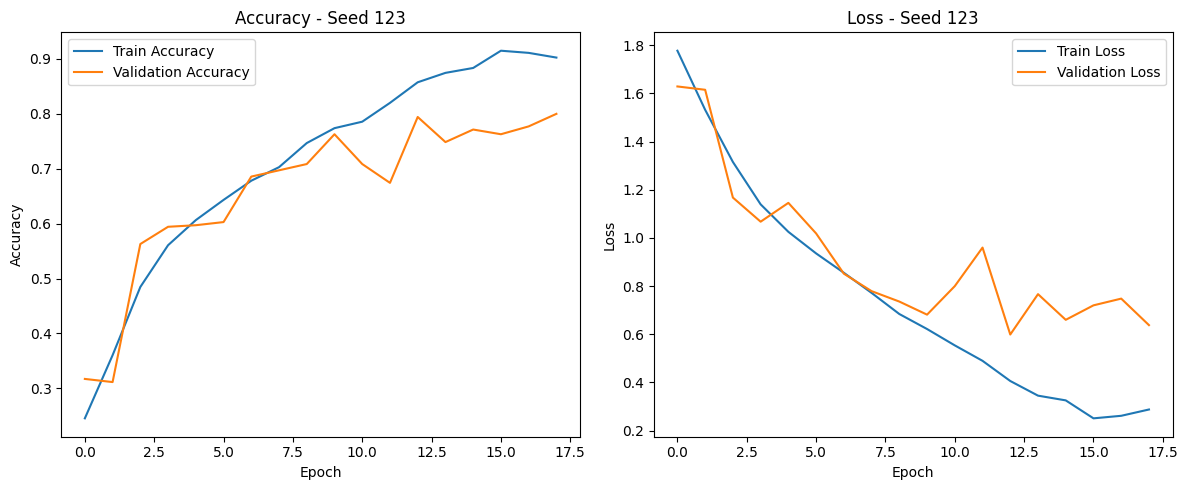


Running seed: 2024
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}
Total parameters: 381,255
Trainable parameters: 381,255
Non-trainable parameters: 0.0
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.1946 - loss: 1.8663 - val_accuracy: 0.2914 - val_loss: 1.6608
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.2907 - loss: 1.6876 - val_accuracy: 0.3171 - val_loss: 1.6441
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3479 - loss: 1.6088 - val_accuracy: 0.2714 - val_loss: 1.7512
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.4413 - loss: 1.4245 - val_accuracy: 0.5029 - val_loss: 1.2959
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.5250 - loss: 1.2180 - val_accuracy: 0.6257 - val_loss: 1.0852
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0

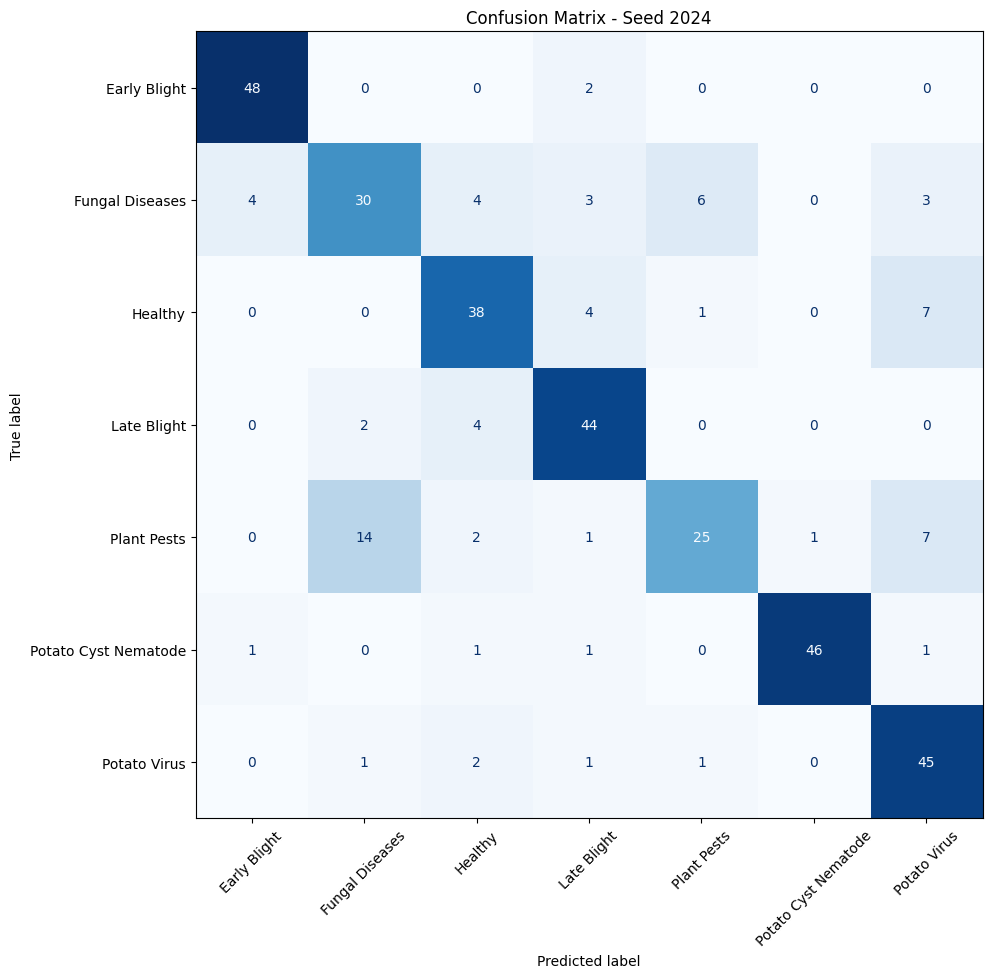

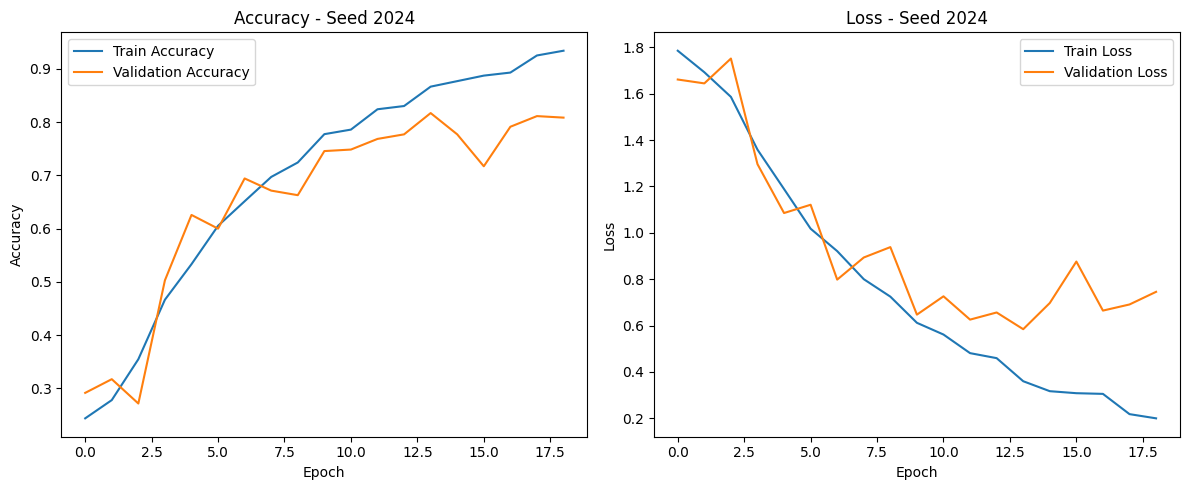


Running seed: 3407
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}
Total parameters: 381,255
Trainable parameters: 381,255
Non-trainable parameters: 0.0
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.2400 - loss: 1.8122 - val_accuracy: 0.2429 - val_loss: 1.6950
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.3175 - loss: 1.6023 - val_accuracy: 0.4457 - val_loss: 1.4260
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.4745 - loss: 1.3695 - val_accuracy: 0.4743 - val_loss: 1.3704
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.5338 - loss: 1.2164 - val_accuracy: 0.5714 - val_loss: 1.1009
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6313 - loss: 0.9740 - val_accuracy: 0.5743 - val_loss: 1.1076
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0

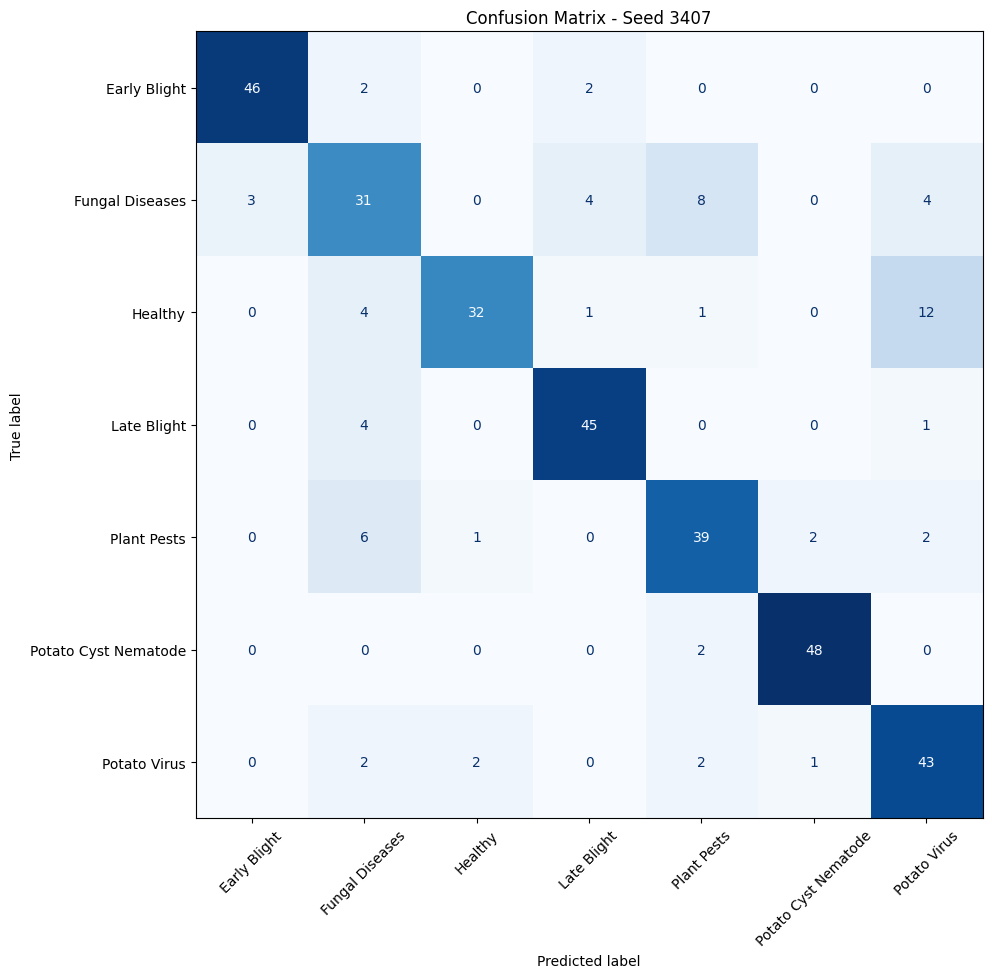

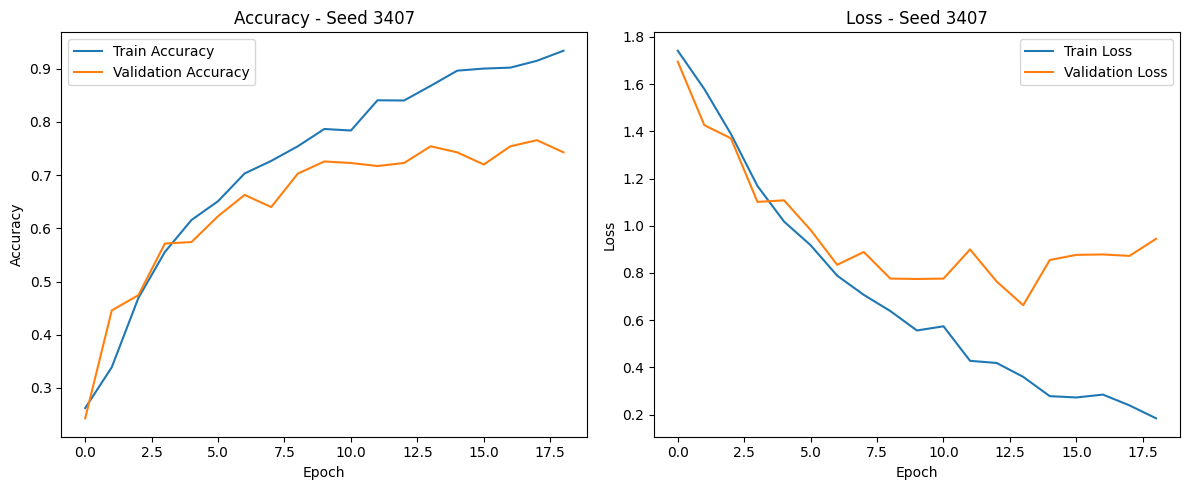


Running seed: 777
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}
Total parameters: 381,255
Trainable parameters: 381,255
Non-trainable parameters: 0.0
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.2270 - loss: 1.8090 - val_accuracy: 0.3514 - val_loss: 1.6375
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.3431 - loss: 1.6060 - val_accuracy: 0.3829 - val_loss: 1.5657
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.4667 - loss: 1.4019 - val_accuracy: 0.5057 - val_loss: 1.2420
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.5693 - loss: 1.1189 - val_accuracy: 0.5714 - val_loss: 1.0386
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.6202 - loss: 1.0086 - val_accuracy: 0.6857 - val_loss: 0.8749
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.

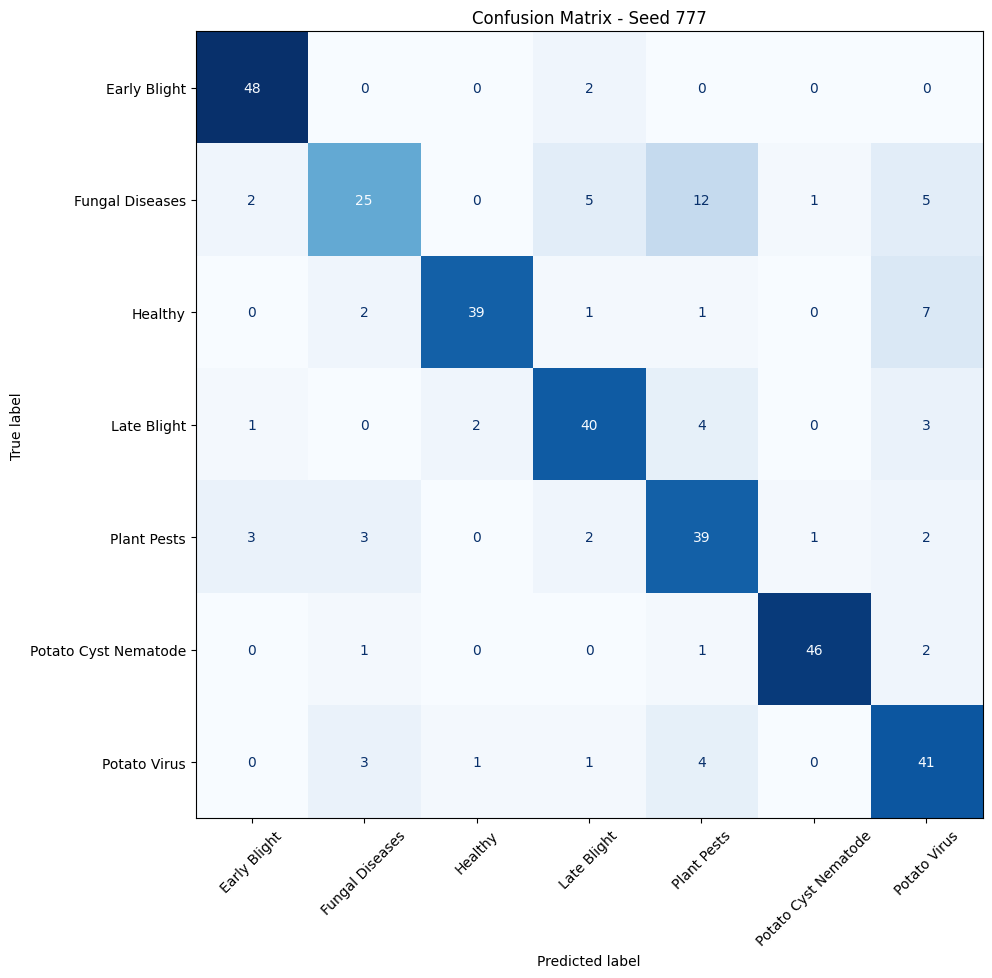

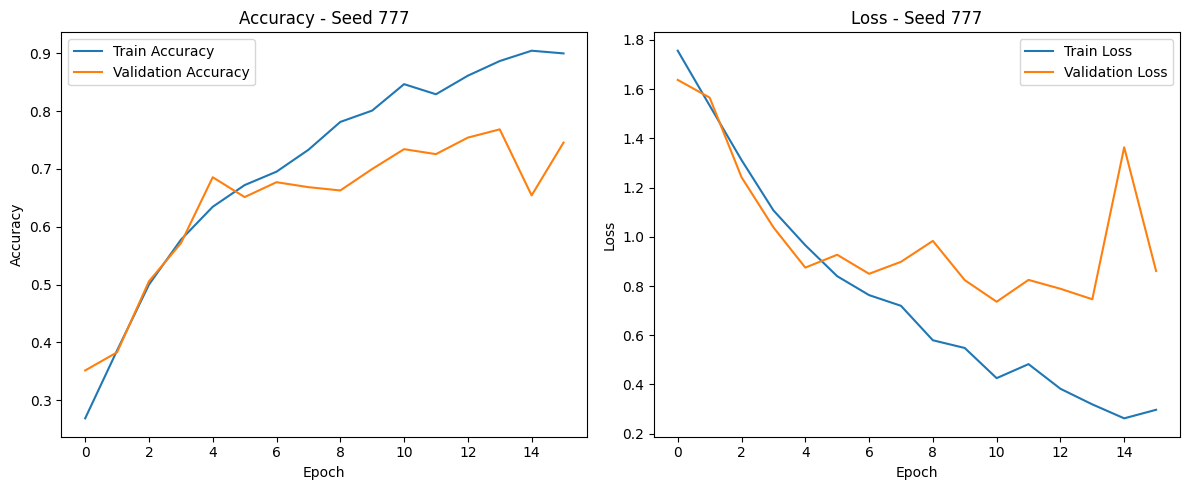


All seed results:
{'seed': 42, 'num_classes': 7, 'test_accuracy': 0.8028571605682373, 'test_loss': 0.654402494430542, 'stopped_epoch': 24, 'best_epoch': 19, 'macro_precision': 0.8000466496863806, 'macro_recall': 0.802857142857143, 'macro_f1': 0.7974796046392306, 'weighted_precision': 0.8000466496863807, 'weighted_recall': 0.8028571428571428, 'weighted_f1': 0.7974796046392306, 'total_params': 381255, 'trainable_params': np.int64(381255), 'non_trainable_params': np.float64(0.0), 'model_path': 'models/CustomLightweightCNN_2_&_7class_seed_42.keras', 'history_path': 'history/CustomLightweightCNN_2_&_7class_seed_42_history.pkl', 'plot_path': 'history/CustomLightweightCNN_2_&_7class_seed_42_accuracy_loss.png', 'confusion_matrix_path': 'history/CustomLightweightCNN_2_&_7class_seed_42_confusion_matrix.png', 'classification_report_path': 'reports/CustomLightweightCNN_2_&_7class_seed_42_classification_report.json'}
{'seed': 123, 'num_classes': 7, 'test_accuracy': 0.8057143092155457, 'test_loss':

In [10]:
all_results = []

for seed in SEEDS:
    result = run_single_seed(seed)
    all_results.append(result)

print("\nAll seed results:")
for result in all_results:
    print(result)


In [11]:
accuracies = np.array([result["test_accuracy"] for result in all_results])
losses = np.array([result["test_loss"] for result in all_results])

print("\nMulti-seed summary")
print("=" * 70)
print(f"Mean accuracy: {np.mean(accuracies):.4f}")
print(f"Standard deviation accuracy: {np.std(accuracies):.4f}")
print(f"Mean loss: {np.mean(losses):.4f}")
print(f"Standard deviation loss: {np.std(losses):.4f}")



Multi-seed summary
Mean accuracy: 0.8006
Standard deviation accuracy: 0.0082
Mean loss: 0.6538
Standard deviation loss: 0.0548


In [12]:
results_df = pd.DataFrame(all_results)

csv_path = f"{EXPERIMENT_NAME}_{NUM_CLASSES}class_multiseed_results.csv"
results_df.to_csv(csv_path, index=False)

print("Saved results to:", csv_path)
results_df


Saved results to: CustomLightweightCNN_2_&_7class_multiseed_results.csv


,seed,num_classes,test_accuracy,test_loss,stopped_epoch,best_epoch,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,total_params,trainable_params,non_trainable_params,model_path,history_path,plot_path,confusion_matrix_path,classification_report_path
0,42,7,0.802857,0.654402,24,19,0.800047,0.802857,0.797480,0.800047,0.802857,0.797480,381255,381255,0.0,models/CustomLightweightCNN_2_&_7class_seed_42...,history/CustomLightweightCNN_2_&_7class_seed_4...,history/CustomLightweightCNN_2_&_7class_seed_4...,history/CustomLightweightCNN_2_&_7class_seed_4...,reports/CustomLightweightCNN_2_&_7class_seed_4...
1,123,7,0.805714,0.574023,18,13,0.819957,0.805714,0.807107,0.819957,0.805714,0.807107,381255,381255,0.0,models/CustomLightweightCNN_2_&_7class_seed_12...,history/CustomLightweightCNN_2_&_7class_seed_1...,history/CustomLightweightCNN_2_&_7class_seed_1...,history/CustomLightweightCNN_2_&_7class_seed_1...,reports/CustomLightweightCNN_2_&_7class_seed_1...
2,2024,7,0.788571,0.672497,19,14,0.789336,0.788571,0.782940,0.789336,0.788571,0.782940,381255,381255,0.0,models/CustomLightweightCNN_2_&_7class_seed_20...,history/CustomLightweightCNN_2_&_7class_seed_2...,history/CustomLightweightCNN_2_&_7class_seed_2...,history/CustomLightweightCNN_2_&_7class_seed_2...,reports/CustomLightweightCNN_2_&_7class_seed_2...
3,3407,7,0.811429,0.741077,19,14,0.819403,0.811429,0.810558,0.819403,0.811429,0.810558,381255,381255,0.0,models/CustomLightweightCNN_2_&_7class_seed_34...,history/CustomLightweightCNN_2_&_7class_seed_3...,history/CustomLightweightCNN_2_&_7class_seed_3...,history/CustomLightweightCNN_2_&_7class_seed_3...,reports/CustomLightweightCNN_2_&_7class_seed_3...
4,777,7,0.794286,0.627209,16,11,0.802583,0.794286,0.792165,0.802583,0.794286,0.792165,381255,381255,0.0,models/CustomLightweightCNN_2_&_7class_seed_77...,history/CustomLightweightCNN_2_&_7class_seed_7...,history/CustomLightweightCNN_2_&_7class_seed_7...,history/CustomLightweightCNN_2_&_7class_seed_7...,reports/CustomLightweightCNN_2_&_7class_seed_7...
